<a href="https://colab.research.google.com/github/konovalovae812-cmd/python_da_hw/blob/main/lisa_HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [7]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

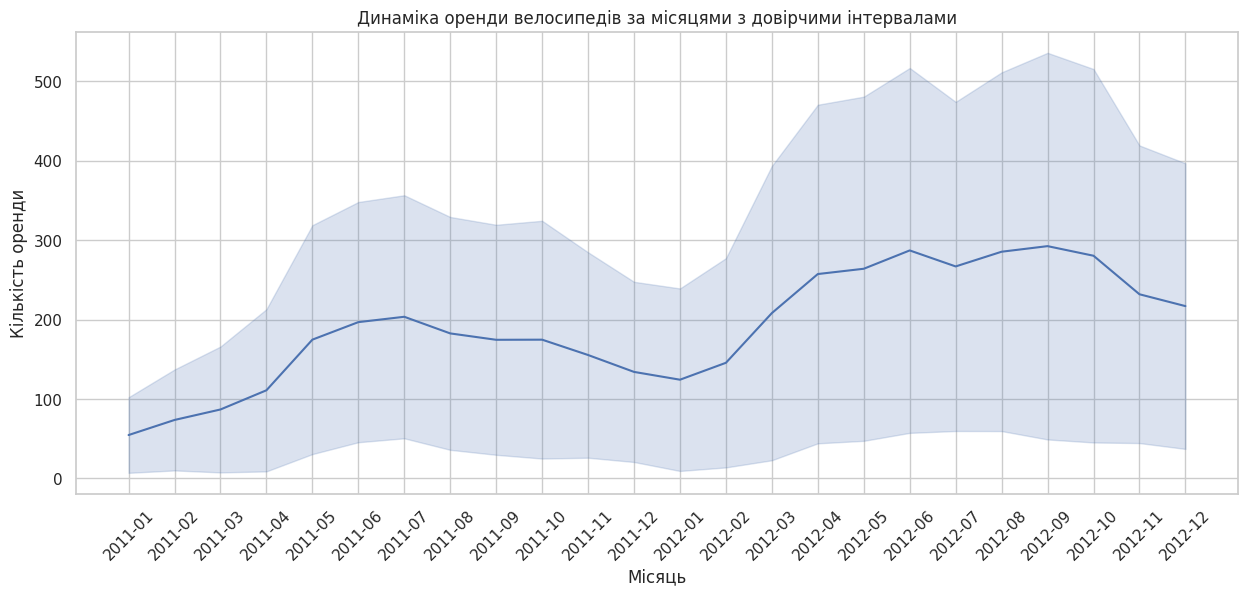

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

sns.lineplot(data=df, x='month_year', y='count', errorbar=('sd', 1))

plt.xticks(rotation=45)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Кількість оренди', fontsize=12)
plt.show()




## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

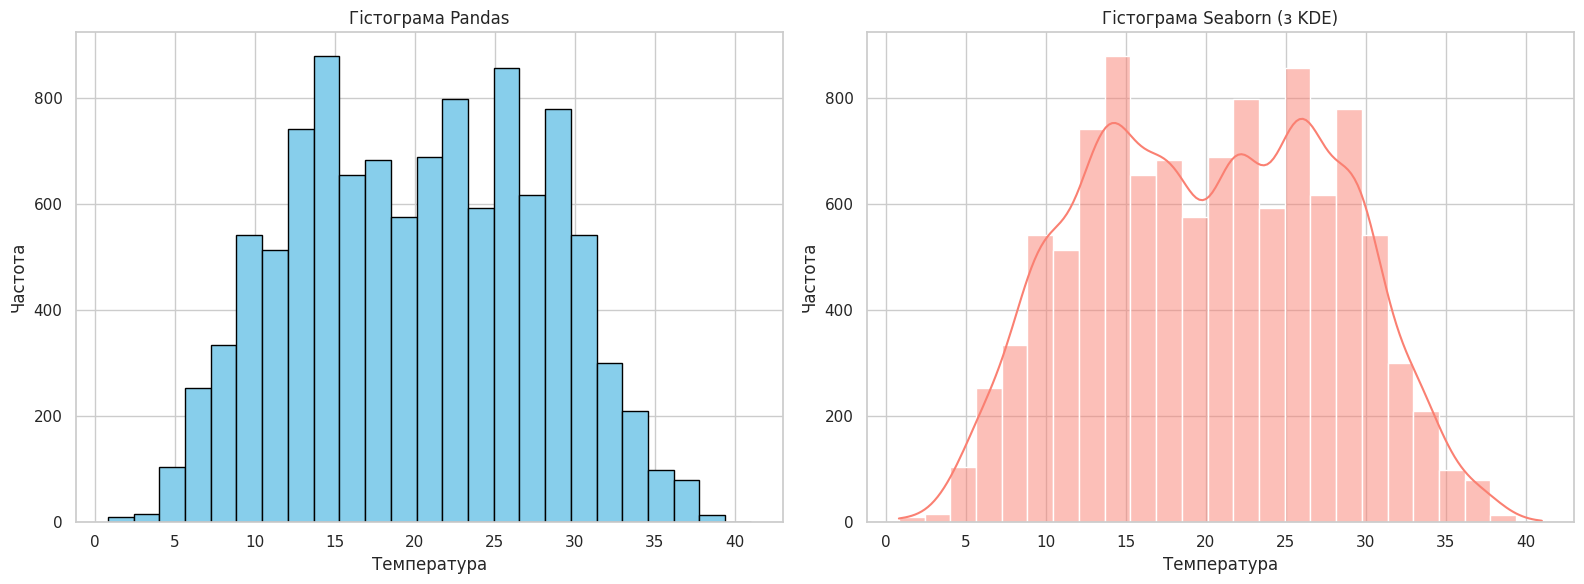

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо фігуру з двома підграфіками (1 рядок, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Гістограма Pandas
df['temp'].hist(bins=25, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Гістограма Pandas')
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

# 2. Гістограма Seaborn
sns.histplot(df['temp'], bins=25, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Гістограма Seaborn (з KDE)')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()


1. У seaborn - візульно більш мякі лінії
2. Лінія - Kernel Density Estimate, допомгає оцінити щільність розподілу, його нормальність

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

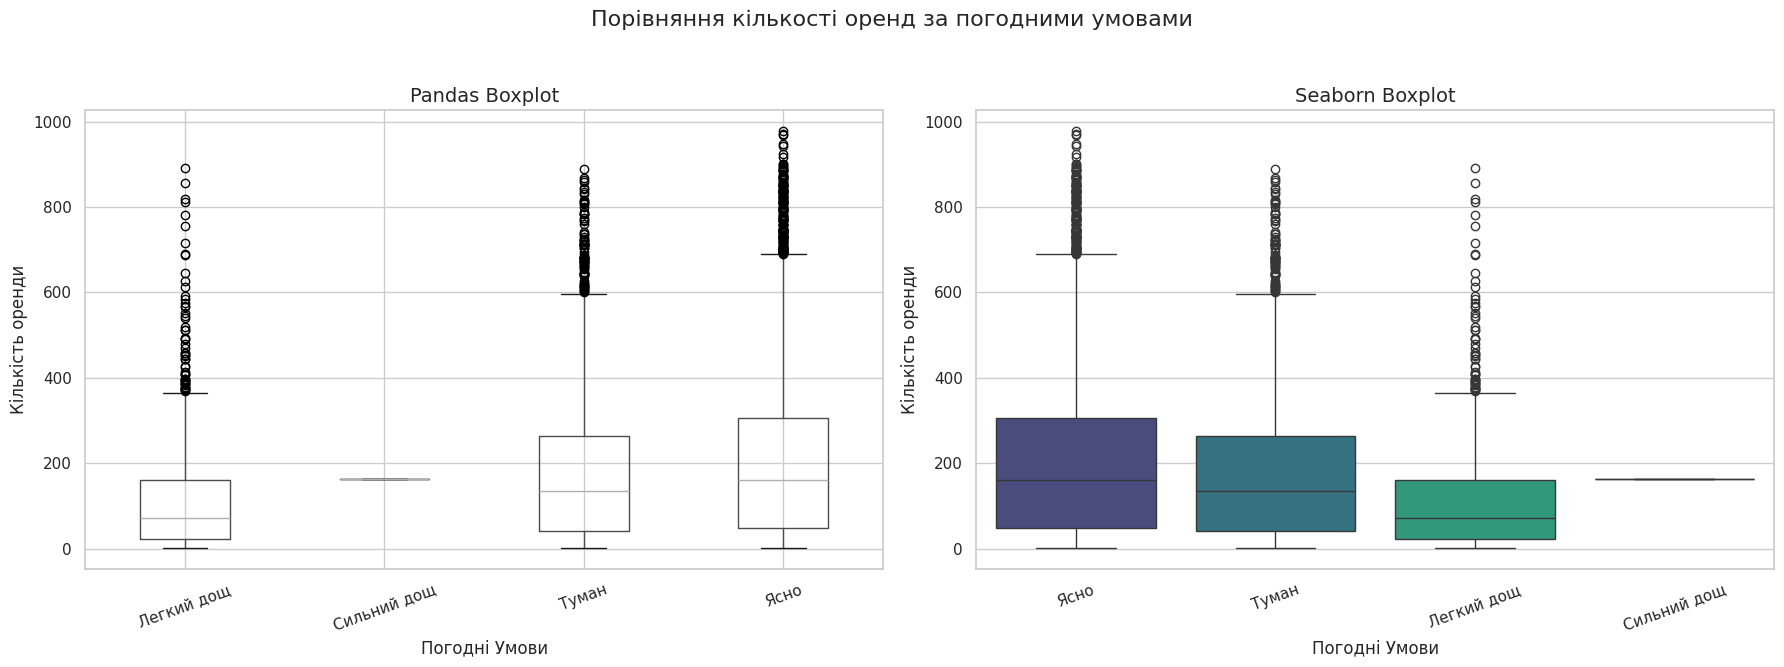

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# Cловник
weather_map = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

# Створюємо колонку з текстовим описом
df['weather_desc'] = df['weather'].map(weather_map)

# Побудова графіків
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Box Plot Pandas
df.boxplot(column='count', by='weather_desc', ax=axes[0])
axes[0].set_title('Pandas Boxplot', fontsize=14)
axes[0].set_xlabel('Погодні Умови')
axes[0].set_ylabel('Кількість оренди')

# Box Plot Seaborn
sns.boxplot(data=df, x='weather_desc', y='count', ax=axes[1],
            hue='weather_desc', palette='viridis', legend=False)
axes[1].set_title('Seaborn Boxplot', fontsize=14)
axes[1].set_xlabel('Погодні Умови')
axes[1].set_ylabel('Кількість оренди')

# Налаштування загального вигляду
for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Порівняння кількості оренд за погодними умовами', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()





Візуальна різниця - seaborn за замовчуванням застосовує різні кольри та більш чіткіші лінії, pandas - будує графіки в одному кольорі

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


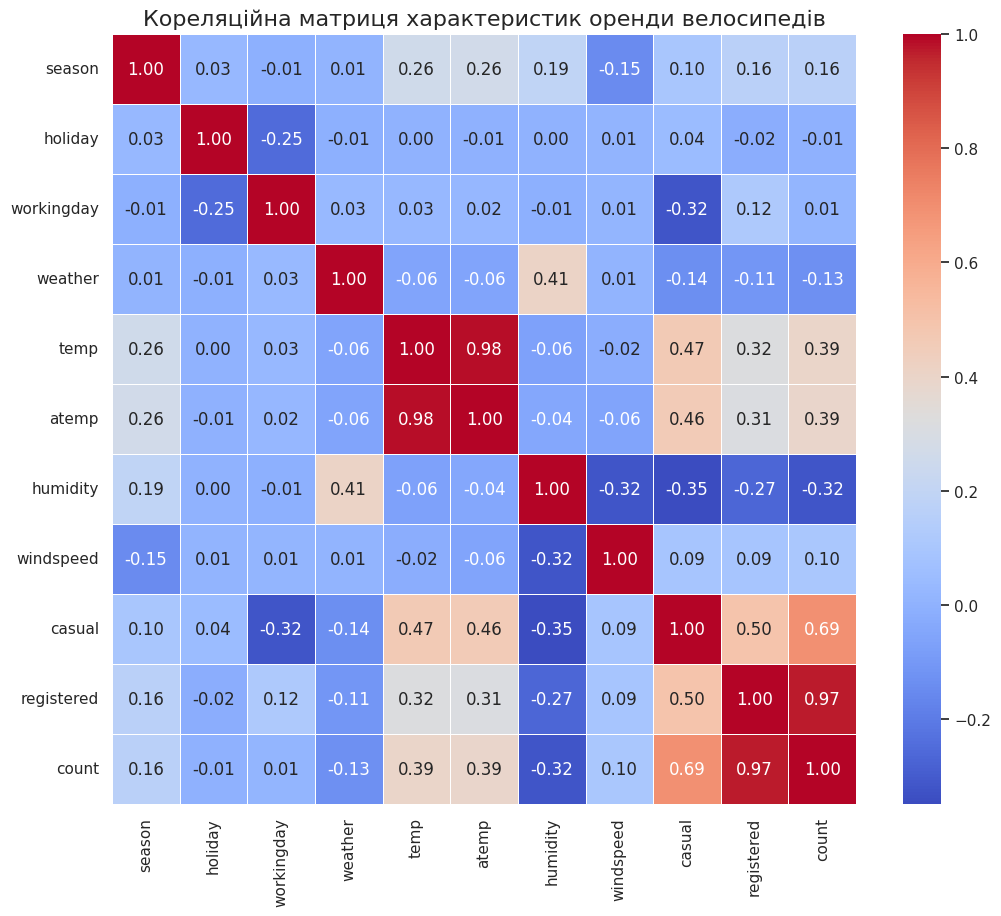

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_corr = ['season', 'holiday', 'workingday', 'weather', 'temp',
                'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
# annot=True додає цифри в клітинки, cmap='coolwarm' робить високу кореляцію червоною, а низьку - синьою
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Кореляційна матриця характеристик оренди велосипедів', fontsize=16)
plt.show()



1. Які змінні найсильніше корелюють з загальною кількістю оренди (count) - casual та registered, але це дуже логічно, бо ці два показники умовни і є загальны кількість. Також мають прямий вплив показники ткмператури, та відчуття температури, то б то ми й далі бачимо, що сезонність має вплив на оренду велосипедів.
2. Яка кореляція між temp та atemp  - 0,98. Така висока кореляція тому що atemp розраховується на основі temp, вони змініються синхронно.
3. humidity та count: чим вища вологість, тим менше оренд.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


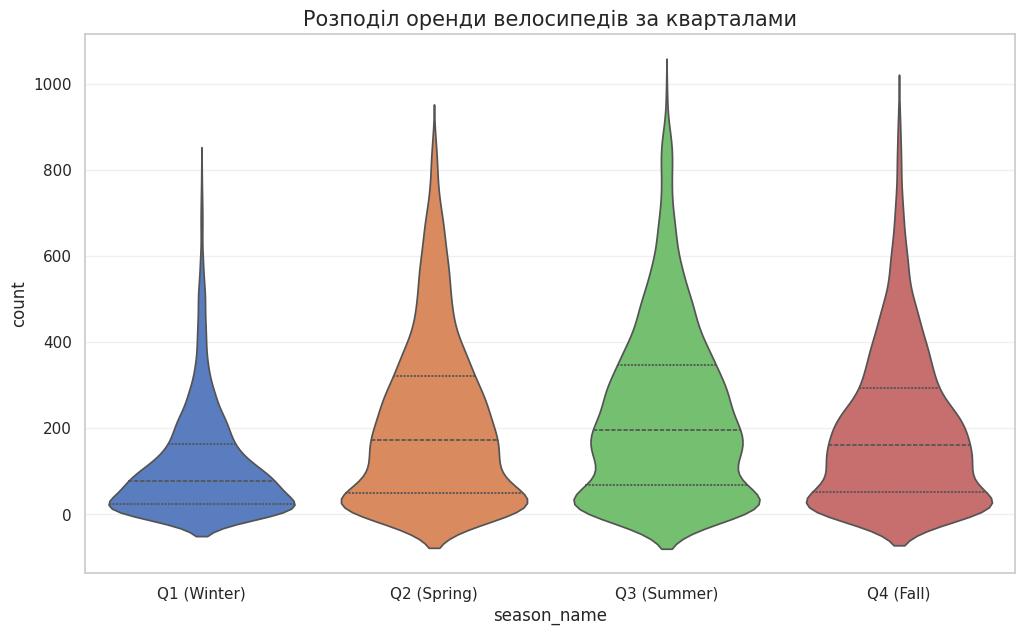

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# назви кварталів
season_map = {1: 'Q1 (Winter)', 2: 'Q2 (Spring)', 3: 'Q3 (Summer)', 4: 'Q4 (Fall)'}
df['season_name'] = df['season'].map(season_map)

# побудова графіку
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df,
    x='season_name',
    y='count',
    hue='season_name',
    palette='muted',
    inner='quartile',
    legend=False
)

plt.title('Розподіл оренди велосипедів за кварталами', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


1. Товщина  показує, як часто зустрічається конкретне значення
2. Найбільша варіабельність  у Q3, бо "скрипка" там найбільш витягнута вертикально.
3. Перевага над box plot у тому, що ми бачимо форму розподілу (піки та провали), а не просто статистичні межі.


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

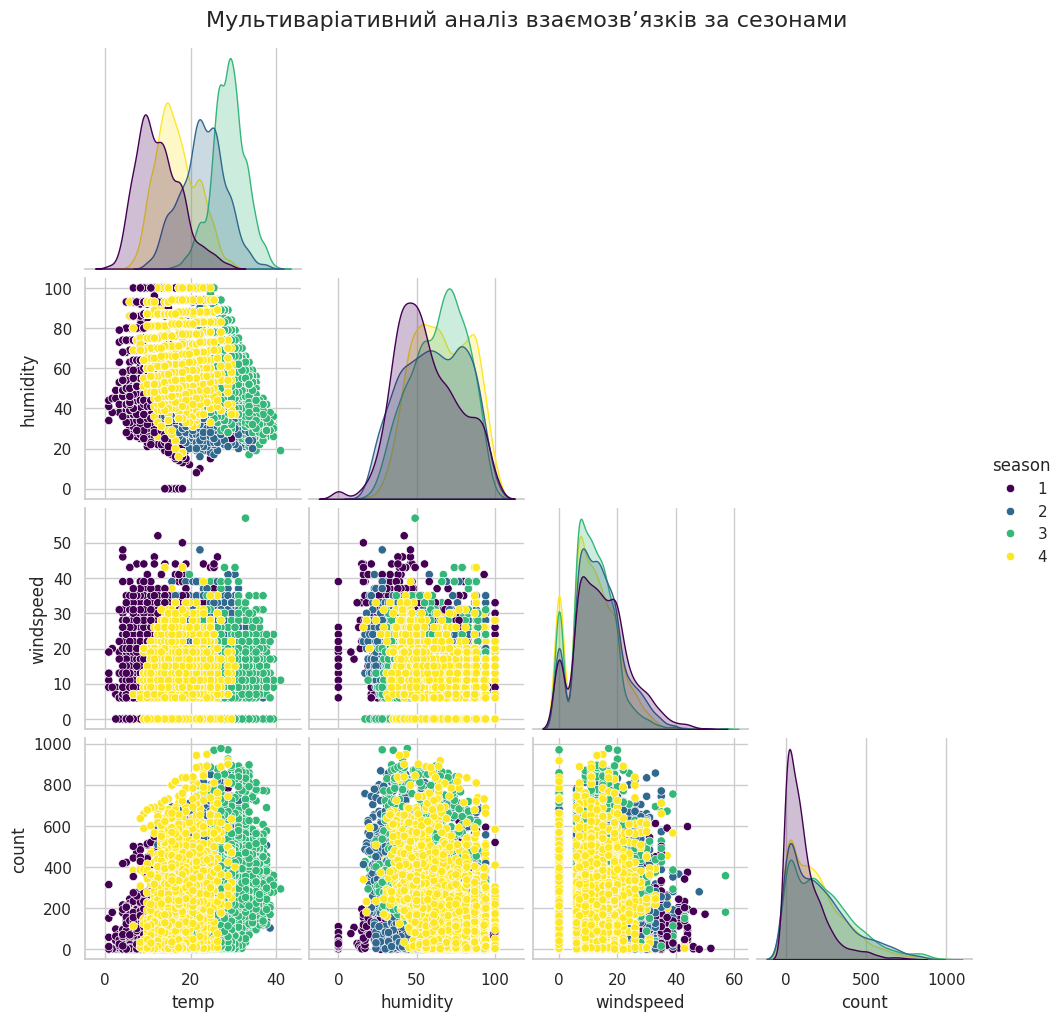

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Вибираємо ключові змінні для аналізу
cols_to_plot = ['temp', 'humidity', 'windspeed', 'count', 'season']

# 2. Будуємо Pairplot
# Параметр corner=True прибирає дубльовані графіки зверху для кращої читабельності
sns.pairplot(data=df[cols_to_plot], hue='season', palette='viridis', corner=True)

plt.suptitle('Мультиваріативний аналіз взаємозв’язків за сезонами', y=1.02, fontsize=16)
plt.show()


## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

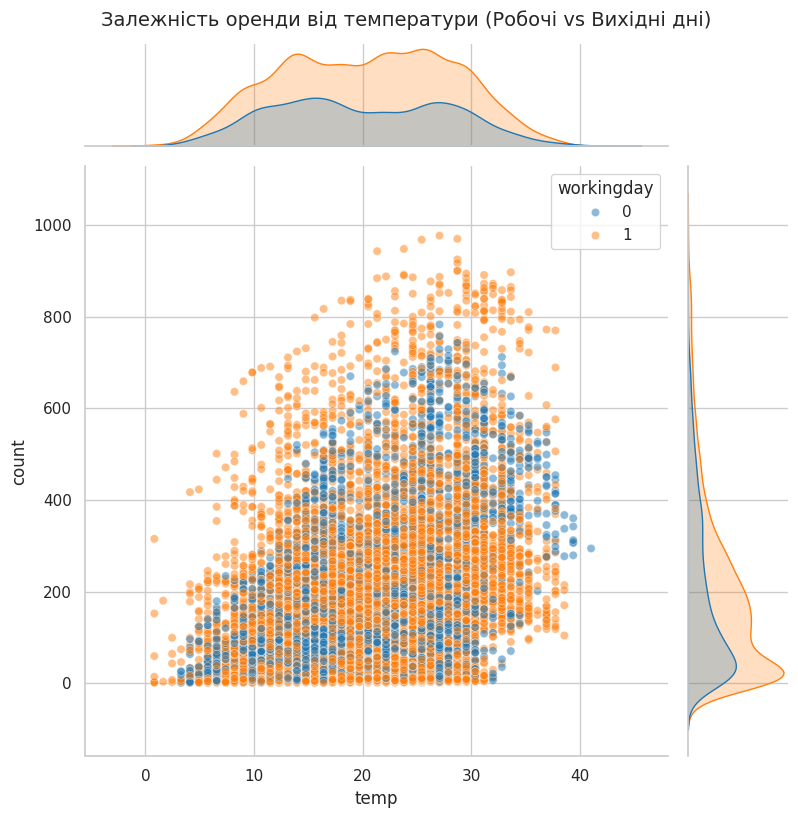

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Побудова Joint Plot
# x='temp' - температура, y='count' - кількість оренд
# hue='workingday' - розділяємо на робочі (1) та вихідні (0) дні
g = sns.jointplot(data=df, x='temp', y='count', hue='workingday',
                  palette='tab10', alpha=0.5, height=8)

# Додавання загального заголовка (вимагає коригування через структуру JointGrid)
g.fig.suptitle('Залежність оренди від температури (Робочі vs Вихідні дні)', y=1.02, fontsize=14)

plt.show()


1. Що показують графіки по краях?
Графіки по краях показують одновимірні розподіли кожної змінної окремо.
Зверху: Розподіл температури (temp) — ми бачимо, які температури зустрічаються найчастіше.
Справа: Розподіл кількості оренд (count) — ми бачимо типову частоту замовлень незалежно від температури.
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?
У робочі дні (workingday=1): Розподіл count на бічному графіку часто має два виражені піки (бімодальний), що відповідає годинам пік (ранок та вечір).
У вихідні дні (workingday=0): Розподіл більш рівномірний ("дзвоноподібний"), оскільки люди катаються протягом усього дня для відпочинку.
Загальна тенденція до зростання кількості оренд при підвищенні температури зберігається для обох типів днів, але хмара точок у робочі дні часто щільніша через стабільні поїздки на роботу.